Notebook for illustrating the optimizations done in the gradient computation on the restricted state space.

In [87]:
import mhn
from mhn.optimizers import Optimizer, Device
import pandas as pd
import time
import matplotlib.pyplot as plt
import math
import numpy as np

np.random.seed(123)


For performance evaluation we are interested in whether CUDA optimizations are available on our machine

In [88]:
mhn.CUDA_AVAILABLE

'CUDA is available'

In [89]:
opt = Optimizer()
opt.set_penalty(opt.Penalty.L1)
opt.set_device(Device.CPU)

In [ ]:
input = pd.read_csv('LUAD_n12.csv')
#input = pd.read_csv('G16_CH_COAD_n31.csv').iloc[:,1:]      #taken from A.Loesch Genie16 repo
input.head()

,APC (M),TP53 (M),ASXL1/20q (Amp),SMAD4/18q (Del),FLT3/13q (Amp),KRAS (M),RAC1/7p (Amp),MYC/8q (Amp),TP53/17p (Del),ID3/1p (Del),...,PTEN (M),ATM (M),AMER1 (M),FAT1 (M),CREBBP (M),KMT2C (M),B2M (M),TGFBR2 (M),NOTCH3 (M),CH
0,1,0,1,1,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,0,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


C:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\mhn\optimizers.py:287: UserWarning: The dtype of the given data matrix is changed to np.int32
  warnings.warn(


[11, 4, 1, 2, 2, 2, 1, 1, 2, 1, 1, 2, 3, 6, 2, 6, 3, 1, 1, 1, 3, 1, 4, 1, 1, 1, 4, 1, 1, 1, 1, 1, 2, 2, 2, 2, 7, 1, 1, 1, 3, 2, 1, 2, 2, 3, 2, 1, 1, 2, 1, 1, 2, 1, 2, 2, 2, 1, 1, 1, 2, 12, 1, 1, 2, 9, 1, 1, 1, 2, 4, 3, 1, 2, 4, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 4, 10, 1, 1, 1, 8, 1, 1, 1, 2, 1, 1, 4, 1, 1, 2, 2, 5, 1, 12, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 3, 1, 3, 2, 1, 2, 1, 1, 4, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 3, 10, 1, 3, 3, 1, 1, 1, 1, 1, 1, 1, 2, 1, 6, 1, 3, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 3, 1, 1, 5, 1, 1, 1, 1, 3, 3, 1, 1, 1, 5, 1, 2, 1, 7, 1, 1, 1, 1, 1, 4, 1, 2, 1, 6, 1, 6, 1, 3, 1, 1, 1, 1, 7, 1, 4, 1, 1, 1, 1, 1, 2, 1, 2, 1, 4, 1, 2, 1, 3, 3, 5, 2, 1, 1, 1, 1, 13, 1, 2, 1, 2, 4, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

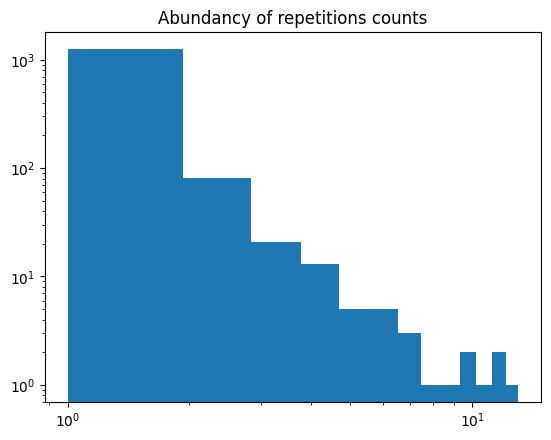

In [91]:
my_data = np.tile(input, (1,1))
#my_data=input
opt.load_data_matrix(my_data, reduce_data_redundancies=True)
data_retrieval, repetitions=opt._data.get_data_repetitions()
print(repetitions)
print(sum(repetitions))
print(f"{len(repetitions)} / {len(my_data)} are unique samples")
plt.hist([r for r in repetitions if r!=0], bins=max(repetitions),)
plt.yscale('log')
plt.xscale('log')
plt.title("Abundancy of repetitions counts")
plt.show()

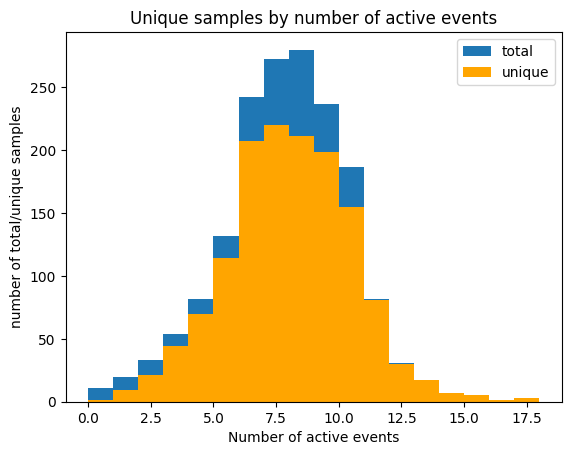

In [92]:
active_events_count = [sum(s) for s in my_data]
compr_active_events_count = [sum(s) for s in data_retrieval]
mut_range = opt._data.get_max_mutation_num()+1

plt.hist(active_events_count, bins=range(mut_range), label="total")
plt.hist(compr_active_events_count, bins=range(mut_range), color='orange', label="unique")
plt.title("Unique samples by number of active events")
plt.ylabel("number of total/unique samples")
plt.xlabel("Number of active events")
#plt.yscale('log')
plt.legend()

Text(0.5, 0, 'Number of active events')

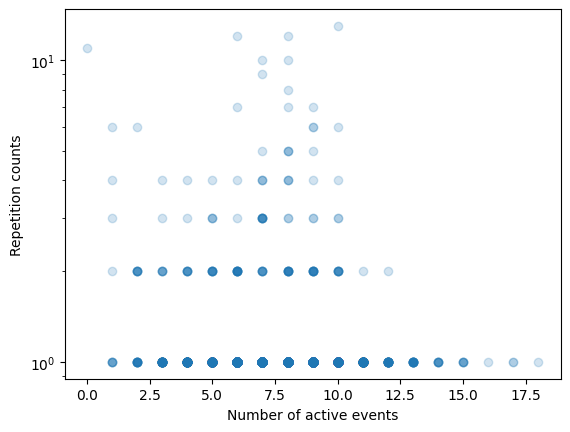

In [93]:
plt.scatter(compr_active_events_count, repetitions, alpha=0.2)
plt.yscale('log')
plt.ylabel("Repetition counts")
plt.xlabel("Number of active events")

In [94]:
#test code
opt._data.compress_data()
compr_data, compr_repetitions = opt._data.get_data_repetitions()
print(repetitions)
print(compr_repetitions)
print(f"{len(compr_repetitions)} unique samples")

[11, 4, 1, 2, 2, 2, 1, 1, 2, 1, 1, 2, 3, 6, 2, 6, 3, 1, 1, 1, 3, 1, 4, 1, 1, 1, 4, 1, 1, 1, 1, 1, 2, 2, 2, 2, 7, 1, 1, 1, 3, 2, 1, 2, 2, 3, 2, 1, 1, 2, 1, 1, 2, 1, 2, 2, 2, 1, 1, 1, 2, 12, 1, 1, 2, 9, 1, 1, 1, 2, 4, 3, 1, 2, 4, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 4, 10, 1, 1, 1, 8, 1, 1, 1, 2, 1, 1, 4, 1, 1, 2, 2, 5, 1, 12, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 3, 1, 3, 2, 1, 2, 1, 1, 4, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 3, 10, 1, 3, 3, 1, 1, 1, 1, 1, 1, 1, 2, 1, 6, 1, 3, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 3, 1, 1, 5, 1, 1, 1, 1, 3, 3, 1, 1, 1, 5, 1, 2, 1, 7, 1, 1, 1, 1, 1, 4, 1, 2, 1, 6, 1, 6, 1, 3, 1, 1, 1, 1, 7, 1, 4, 1, 1, 1, 1, 1, 2, 1, 2, 1, 4, 1, 2, 1, 3, 3, 5, 2, 1, 1, 1, 1, 13, 1, 2, 1, 2, 4, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [95]:
print(opt._data.get_max_mutation_num())

18


In [96]:
#opt.train(5/len(input))

In [97]:
#opt.result.plot()
#plt.show()

In [98]:
data_split = [input[[sum(input.loc[row]) == mut_count for row in input.index]] for mut_count in range(mut_range)]

In [101]:
act_events_comp_times_compr=[]
act_events_comp_times_nocompr = []


for i,uniform_data in enumerate(data_split):
    print(i)
    opt.load_data_matrix(uniform_data, reduce_data_redundancies=False)
    start = time.process_time()
    opt.train(maxit=5, reltol=0)      
    end = time.process_time()
    act_events_comp_times_nocompr.append(end-start)
    
    
    opt.load_data_matrix(uniform_data, reduce_data_redundancies=True)
    start = time.process_time()
    opt.train(maxit=5, reltol=0)      
    end = time.process_time()
    act_events_comp_times_compr.append(end-start)

0
1
2
3
4


C:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\mhn\optimizers.py:415: UserWarning: Your data does not contain any mutations, something went probably wrong
  self._data = StateContainer(data_matrix, reduce_data_redundancies)
C:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\mhn\optimizers.py:645: UserWarning: During independence model creation: event 0 never occurs in the data, base rate will be 0
  vanilla_theta = create_indep_model(self._data)
C:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\mhn\optimizers.py:645: UserWarning: During independence model creation: event 1 never occurs in the data, base rate will be 0
  vanilla_theta = create_indep_model(self._data)
C:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\mhn\optimizers.py:645: UserWarning: During independence model creation: event 2 never occurs in the data, base rate will be 0
  vanilla_theta = create_indep_model(self._data)
C:\Users\michi\Uni\SHK_Spang\learnmhn_state-sp

5
6
7
8
9
10
11
12
13
14
15
16
17
18


Text(0.5, 0, 'Number of active events')

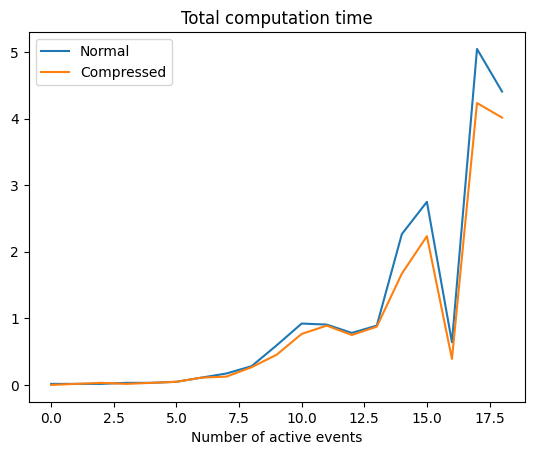

In [102]:
plt.plot(act_events_comp_times_nocompr, label="Normal")
plt.plot(act_events_comp_times_compr, label="Compressed")
plt.legend()
plt.title("Total computation time")
plt.xlabel("Number of active events")

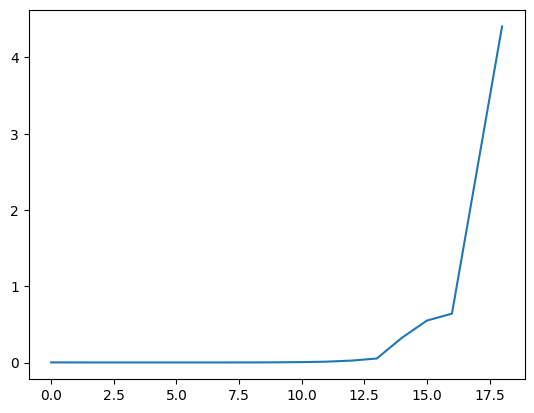

In [103]:
avg_comp_time = [act_events_comp_times_nocompr[i]/len(data_split[i]) for i in range(mut_range)]
plt.plot(avg_comp_time)

In [47]:
dataset_fractions = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9]
N=len(input)
computation_speeds={frac:[] for frac in dataset_fractions}
max_it = 200

repetitions=3
for i in range(repetitions):
    for dataset_fraction in dataset_fractions:
        input_subset = np.tile(input, (math.ceil(dataset_fraction),1))[:int(N*dataset_fraction)]
        

        #input_subset = input.sample(frac=dataset_fraction, replace=True, random_state=6)
        start_prep = time.process_time()
        opt.load_data_matrix(input_subset)
        opt._data.compress_data()
        end_prep = time.process_time()


        print(f"{dataset_fraction} fraction of dataset ({len(input_subset)}) ")

        #measure time optimization takes
        start = time.process_time()
    
        opt.train(maxit=max_it)      
        end = time.process_time()

        time_elapsed= end-start
        computation_speeds[dataset_fraction].append(time_elapsed)
        print(f"Preparation time: {end_prep-start_prep}\t CPU time: {time_elapsed} seconds")

C:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\mhn\optimizers.py:287: UserWarning: The dtype of the given data matrix is changed to np.int32
  warnings.warn(


0.1 fraction of dataset (366) 
Preparation time: 0.0	 CPU time: 0.625 seconds
0.25 fraction of dataset (915) 
Preparation time: 0.0	 CPU time: 0.859375 seconds
0.5 fraction of dataset (1831) 
Preparation time: 0.0	 CPU time: 1.34375 seconds
0.75 fraction of dataset (2746) 
Preparation time: 0.0	 CPU time: 1.328125 seconds
1 fraction of dataset (3662) 
Preparation time: 0.0	 CPU time: 1.5 seconds
1.5 fraction of dataset (5493) 
Preparation time: 0.015625	 CPU time: 1.515625 seconds
2 fraction of dataset (7324) 
Preparation time: 0.015625	 CPU time: 1.59375 seconds
3 fraction of dataset (10986) 
Preparation time: 0.015625	 CPU time: 1.65625 seconds
4 fraction of dataset (14648) 
Preparation time: 0.0	 CPU time: 1.671875 seconds
5 fraction of dataset (18310) 
Preparation time: 0.015625	 CPU time: 1.796875 seconds
6 fraction of dataset (21972) 
Preparation time: 0.015625	 CPU time: 1.859375 seconds
7 fraction of dataset (25634) 
Preparation time: 0.046875	 CPU time: 2.34375 seconds
8 fract

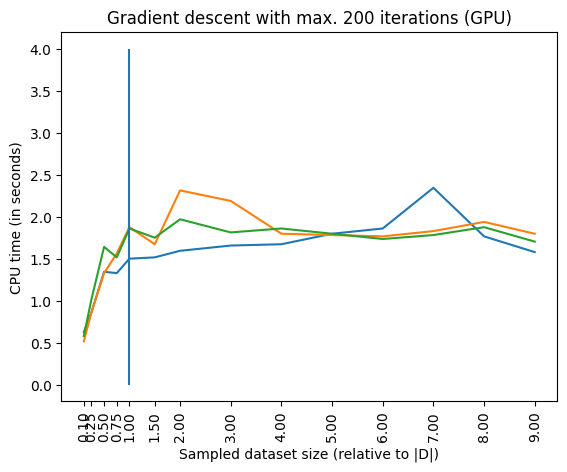

In [48]:
comp_speeds_df=pd.DataFrame.from_dict(computation_speeds)
comp_speeds_df.T.plot(xlabel="Sampled dataset size (relative to |D|)", ylabel="CPU time (in seconds)", xticks=dataset_fractions, legend=False)
plt.xticks(rotation=90)
plt.title(f"Gradient descent with max. {max_it} iterations (GPU)")

plt.vlines(1,0,4)

In [49]:


dataset_fractions = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
N=len(input)
computation_times={frac:[] for frac in dataset_fractions}

repetitions=3
for i in range(repetitions):
    for dataset_fraction in dataset_fractions:
        input_subset = np.tile(input, (math.ceil(dataset_fraction),1))[:int(N*dataset_fraction)]
        

        #input_subset = input.sample(frac=dataset_fraction, replace=True, random_state=6)
        start_prep = time.process_time()
        opt.load_data_matrix(input_subset)
        opt._data.compress_data()
        end_prep = time.process_time()


        print(f"{dataset_fraction} fraction of dataset ({len(input_subset)}) ")

        #measure time optimization takes
        start = time.process_time()
        
        my_lam = 1.0/len(input_subset)
        if dataset_fraction > 1:
            my_lam = 1.0/N  # fix one value for lambda to have comparable score landscapes (for "full" datasets)
        opt.train(lam = my_lam)      
        end = time.process_time()

        time_elapsed= end-start
        computation_times[dataset_fraction].append(time_elapsed)
        print(f"Preparation time: {end_prep-start_prep}\t CPU time: {time_elapsed} seconds")

C:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\mhn\optimizers.py:287: UserWarning: The dtype of the given data matrix is changed to np.int32
  warnings.warn(


0.1 fraction of dataset (366) 
Preparation time: 0.0	 CPU time: 0.578125 seconds
0.25 fraction of dataset (915) 
Preparation time: 0.0	 CPU time: 0.9375 seconds
0.5 fraction of dataset (1831) 
Preparation time: 0.0	 CPU time: 1.328125 seconds
0.75 fraction of dataset (2746) 
Preparation time: 0.0	 CPU time: 1.828125 seconds
1 fraction of dataset (3662) 
Preparation time: 0.0	 CPU time: 2.75 seconds
1.5 fraction of dataset (5493) 
Preparation time: 0.0	 CPU time: 1.84375 seconds
2 fraction of dataset (7324) 
Preparation time: 0.0	 CPU time: 2.78125 seconds
3 fraction of dataset (10986) 
Preparation time: 0.015625	 CPU time: 2.0625 seconds
4 fraction of dataset (14648) 
Preparation time: 0.015625	 CPU time: 2.390625 seconds
5 fraction of dataset (18310) 
Preparation time: 0.015625	 CPU time: 2.296875 seconds
6 fraction of dataset (21972) 
Preparation time: 0.015625	 CPU time: 2.40625 seconds
7 fraction of dataset (25634) 
Preparation time: 0.046875	 CPU time: 2.859375 seconds
8 fraction 

In [50]:
comp_times_df=pd.DataFrame.from_dict(computation_times)

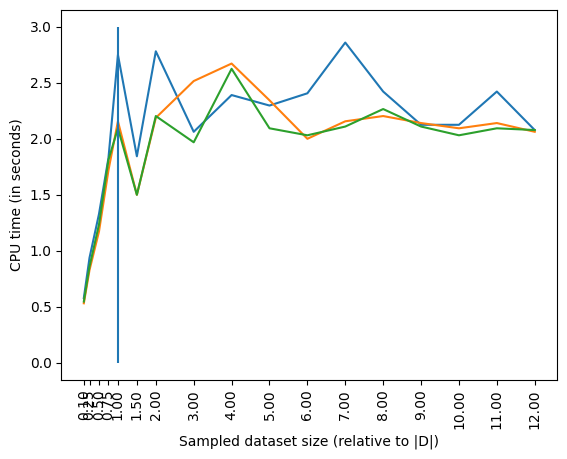

In [51]:
comp_times_df.T.plot(xlabel="Sampled dataset size (relative to |D|)", ylabel="CPU time (in seconds)", xticks=dataset_fractions, legend=False)
plt.xticks(rotation=90)

plt.vlines(1,0,3)